## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Importing Dataset

In [2]:
results = pd.read_csv('results.csv')
goalscorers = pd.read_csv('goalscorers.csv')
shootouts = pd.read_csv('shootouts.csv')
former_names = pd.read_csv('former_names.csv')

In [3]:
results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


In [4]:
goalscorers.head()

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False


In [5]:
shootouts.head()

,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,NaN
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN
2,1972-05-07,South Korea,Iraq,Iraq,NaN
3,1972-05-17,Thailand,South Korea,South Korea,NaN
4,1972-05-19,Thailand,Cambodia,Thailand,NaN


In [6]:
former_names.head()

,current,former,start_date,end_date
0,Benin,Dahomey,1959-11-08,1975-11-30
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10
3,Czechoslovakia,Bohemia,1903-04-05,1919-01-01
4,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01


## results

### Data Cleaning & Manipulation

In [7]:
results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


In [8]:
results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49547 entries, 0 to 49546
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        49547 non-null  object
 1   home_team   49547 non-null  object
 2   away_team   49547 non-null  object
 3   home_score  49547 non-null  int64 
 4   away_score  49547 non-null  int64 
 5   tournament  49547 non-null  object
 6   city        49547 non-null  object
 7   country     49547 non-null  object
 8   neutral     49547 non-null  bool  
dtypes: bool(1), int64(2), object(6)
memory usage: 3.1+ MB


In [9]:
# Checking for missing values
pd.isna(results).sum()

date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

In [10]:
results.duplicated().sum()

0

In [11]:
results.shape

(49547, 9)

In [12]:
# checking 'date' datatype
type(results['date'][0])

str

In [13]:
# converting it to datetime format
results['date'] = pd.to_datetime(results['date'])
type(results['date'][0])

pandas._libs.tslibs.timestamps.Timestamp

In [14]:
# creating 'match_outcome' column (finding diff of goals, creating function and using apply method on diff column)
results['diff'] = results['home_score'] - results['away_score']

def match_result(num):
    if num > 0:
        return 'Home Win'
    elif num < 0:
        return 'Away Win'
    else:
        return 'Draw'

results['match_outcome'] = results['diff'].apply(match_result)

results.head(10)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,diff,match_outcome
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,0,Draw
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,2,Home Win
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,1,Home Win
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,0,Draw
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,3,Home Win
5,1876-03-25,Scotland,Wales,4,0,Friendly,Glasgow,Scotland,False,4,Home Win
6,1877-03-03,England,Scotland,1,3,Friendly,London,England,False,-2,Away Win
7,1877-03-05,Wales,Scotland,0,2,Friendly,Wrexham,Wales,False,-2,Away Win
8,1878-03-02,Scotland,England,7,2,Friendly,Glasgow,Scotland,False,5,Home Win
9,1878-03-23,Scotland,Wales,9,0,Friendly,Glasgow,Scotland,False,9,Home Win


In [15]:
# creating 'GD' (goal difference) column
results['GD'] = abs(results['diff'])
results.drop(['diff'], axis = 1, inplace = True)

results.tail()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,match_outcome,GD
49542,2026-08-16,Malaysia,Vietnam,0,2,ASEAN Championship,Kuala Lumpur,Malaysia,False,Away Win,2
49543,2026-08-18,Thailand,Singapore,1,2,ASEAN Championship,Bangkok,Thailand,False,Away Win,1
49544,2026-08-19,Vietnam,Malaysia,2,0,ASEAN Championship,Hanoi,Vietnam,False,Home Win,2
49545,2026-08-22,Thailand,Vietnam,0,2,ASEAN Championship,Bangkok,Thailand,False,Away Win,2
49546,2026-08-26,Vietnam,Thailand,2,2,ASEAN Championship,Hanoi,Vietnam,False,Draw,0


In [16]:
# Creating 'total_goals' scored column
results['total_goals'] = results['home_score'] + results['away_score']
results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,match_outcome,GD,total_goals
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,Draw,0,0
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,Home Win,2,6
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,Home Win,1,3
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,Draw,0,4
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,Home Win,3,3


In [17]:
# Extracting month, year and decade values from 'date' column
list_months = []
for i in range(results.shape[0]):
    list_months.append(results['date'][i].month)
results['Month'] = list_months

list_year = []
for i in range(results.shape[0]):
    list_year.append(results['date'][i].year)
results['Year'] = list_year

list_decade = []
for i in range(results.shape[0]):
    list_decade.append(int(results['date'][i].year/10) * 10)
results['Decade'] = list_decade

results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,match_outcome,GD,total_goals,Month,Year,Decade
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,Draw,0,0,11,1872,1870
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,Home Win,2,6,3,1873,1870
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,Home Win,1,3,3,1874,1870
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,Draw,0,4,3,1875,1870
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,Home Win,3,3,3,1876,1870


In [18]:
# renaming columns
results.rename(columns = {'neutral':'is_neutral_venue'}, inplace = True)
results.tail()

,date,home_team,away_team,home_score,away_score,tournament,city,country,is_neutral_venue,match_outcome,GD,total_goals,Month,Year,Decade
49542,2026-08-16,Malaysia,Vietnam,0,2,ASEAN Championship,Kuala Lumpur,Malaysia,False,Away Win,2,2,8,2026,2020
49543,2026-08-18,Thailand,Singapore,1,2,ASEAN Championship,Bangkok,Thailand,False,Away Win,1,3,8,2026,2020
49544,2026-08-19,Vietnam,Malaysia,2,0,ASEAN Championship,Hanoi,Vietnam,False,Home Win,2,2,8,2026,2020
49545,2026-08-22,Thailand,Vietnam,0,2,ASEAN Championship,Bangkok,Thailand,False,Away Win,2,2,8,2026,2020
49546,2026-08-26,Vietnam,Thailand,2,2,ASEAN Championship,Hanoi,Vietnam,False,Draw,0,4,8,2026,2020


In [19]:
# creating 'winner_team' column
results['winner_team'] = np.where(results['match_outcome'] == 'Home Win', results['home_team'],
                                 np.where(results['match_outcome'] == 'Away Win', results['away_team'], 'Draw'))
results.tail()

,date,home_team,away_team,home_score,away_score,tournament,city,country,is_neutral_venue,match_outcome,GD,total_goals,Month,Year,Decade,winner_team
49542,2026-08-16,Malaysia,Vietnam,0,2,ASEAN Championship,Kuala Lumpur,Malaysia,False,Away Win,2,2,8,2026,2020,Vietnam
49543,2026-08-18,Thailand,Singapore,1,2,ASEAN Championship,Bangkok,Thailand,False,Away Win,1,3,8,2026,2020,Singapore
49544,2026-08-19,Vietnam,Malaysia,2,0,ASEAN Championship,Hanoi,Vietnam,False,Home Win,2,2,8,2026,2020,Vietnam
49545,2026-08-22,Thailand,Vietnam,0,2,ASEAN Championship,Bangkok,Thailand,False,Away Win,2,2,8,2026,2020,Vietnam
49546,2026-08-26,Vietnam,Thailand,2,2,ASEAN Championship,Hanoi,Vietnam,False,Draw,0,4,8,2026,2020,Draw


In [20]:
# creating 'matchup' and 'scoreline' columns
results['matchup'] = results['home_team'] + '-' + results['away_team']
results['scoreline'] = results['home_score'].astype('str') + '-' + results['away_score'].astype('str')
results.head(10)

,date,home_team,away_team,home_score,away_score,tournament,city,country,is_neutral_venue,match_outcome,GD,total_goals,Month,Year,Decade,winner_team,matchup,scoreline
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,Draw,0,0,11,1872,1870,Draw,Scotland-England,0-0
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,Home Win,2,6,3,1873,1870,England,England-Scotland,4-2
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,Home Win,1,3,3,1874,1870,Scotland,Scotland-England,2-1
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,Draw,0,4,3,1875,1870,Draw,England-Scotland,2-2
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,Home Win,3,3,3,1876,1870,Scotland,Scotland-England,3-0
5,1876-03-25,Scotland,Wales,4,0,Friendly,Glasgow,Scotland,False,Home Win,4,4,3,1876,1870,Scotland,Scotland-Wales,4-0
6,1877-03-03,England,Scotland,1,3,Friendly,London,England,False,Away Win,2,4,3,1877,1870,Scotland,England-Scotland,1-3
7,1877-03-05,Wales,Scotland,0,2,Friendly,Wrexham,Wales,False,Away Win,2,2,3,1877,1870,Scotland,Wales-Scotland,0-2
8,1878-03-02,Scotland,England,7,2,Friendly,Glasgow,Scotland,False,Home Win,5,9,3,1878,1870,Scotland,Scotland-England,7-2
9,1878-03-23,Scotland,Wales,9,0,Friendly,Glasgow,Scotland,False,Home Win,9,9,3,1878,1870,Scotland,Scotland-Wales,9-0


In [21]:
# Creating new column 'goals_by_winner' (indicates total goals scored by winner team) 
results['goals_by_winner'] = np.where(results['match_outcome'] == 'Home Win', results['home_score'], 
                                     np.where(results['match_outcome'] == 'Away Win', results['away_score'], results['home_score']))
results.tail(10)

,date,home_team,away_team,home_score,away_score,tournament,city,country,is_neutral_venue,match_outcome,GD,total_goals,Month,Year,Decade,winner_team,matchup,scoreline,goals_by_winner
49537,2026-08-07,Vietnam,Cambodia,3,1,ASEAN Championship,Hanoi,Vietnam,False,Home Win,2,4,8,2026,2020,Vietnam,Vietnam-Cambodia,3-1,3
49538,2026-08-07,Singapore,Indonesia,1,1,ASEAN Championship,Kallang,Singapore,False,Draw,0,2,8,2026,2020,Draw,Singapore-Indonesia,1-1,1
49539,2026-08-08,Thailand,Myanmar,2,0,ASEAN Championship,Bangkok,Thailand,False,Home Win,2,2,8,2026,2020,Thailand,Thailand-Myanmar,2-0,2
49540,2026-08-08,Malaysia,Philippines,1,0,ASEAN Championship,Kuala Lumpur,Malaysia,False,Home Win,1,1,8,2026,2020,Malaysia,Malaysia-Philippines,1-0,1
49541,2026-08-15,Singapore,Thailand,1,3,ASEAN Championship,Kallang,Singapore,False,Away Win,2,4,8,2026,2020,Thailand,Singapore-Thailand,1-3,3
49542,2026-08-16,Malaysia,Vietnam,0,2,ASEAN Championship,Kuala Lumpur,Malaysia,False,Away Win,2,2,8,2026,2020,Vietnam,Malaysia-Vietnam,0-2,2
49543,2026-08-18,Thailand,Singapore,1,2,ASEAN Championship,Bangkok,Thailand,False,Away Win,1,3,8,2026,2020,Singapore,Thailand-Singapore,1-2,2
49544,2026-08-19,Vietnam,Malaysia,2,0,ASEAN Championship,Hanoi,Vietnam,False,Home Win,2,2,8,2026,2020,Vietnam,Vietnam-Malaysia,2-0,2
49545,2026-08-22,Thailand,Vietnam,0,2,ASEAN Championship,Bangkok,Thailand,False,Away Win,2,2,8,2026,2020,Vietnam,Thailand-Vietnam,0-2,2
49546,2026-08-26,Vietnam,Thailand,2,2,ASEAN Championship,Hanoi,Vietnam,False,Draw,0,4,8,2026,2020,Draw,Vietnam-Thailand,2-2,2


### EDA

#### Total matches played in each FIFA World Cup

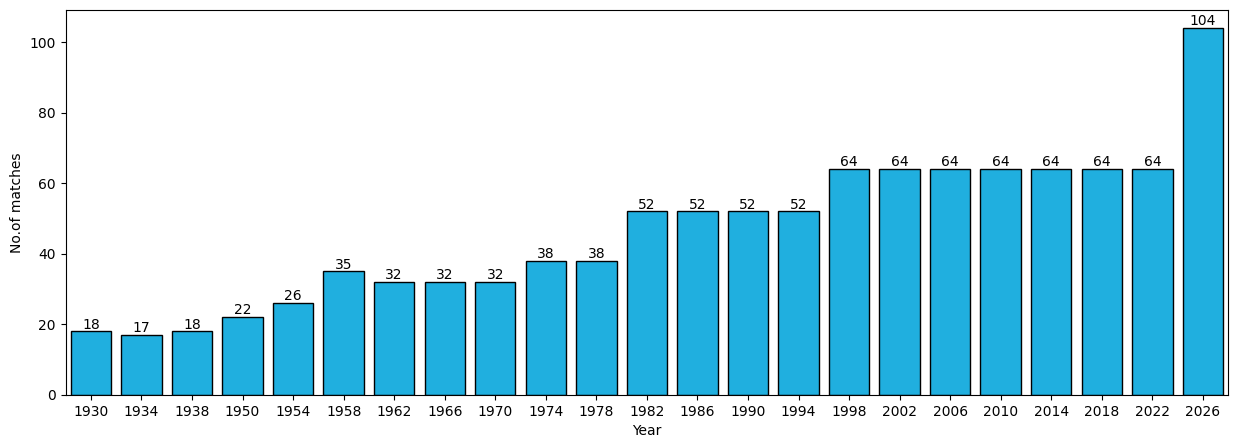

In [22]:
plt.figure(figsize = (15,5))
ax = sns.countplot(data = results[results['tournament'] == 'FIFA World Cup'], x = 'Year', color = 'deepskyblue', edgecolor = 'black')
for bars in ax.containers:
    ax.bar_label(bars)
plt.ylabel('No.of matches')
plt.show()

#### Total goals scored in each FIFA World Cup

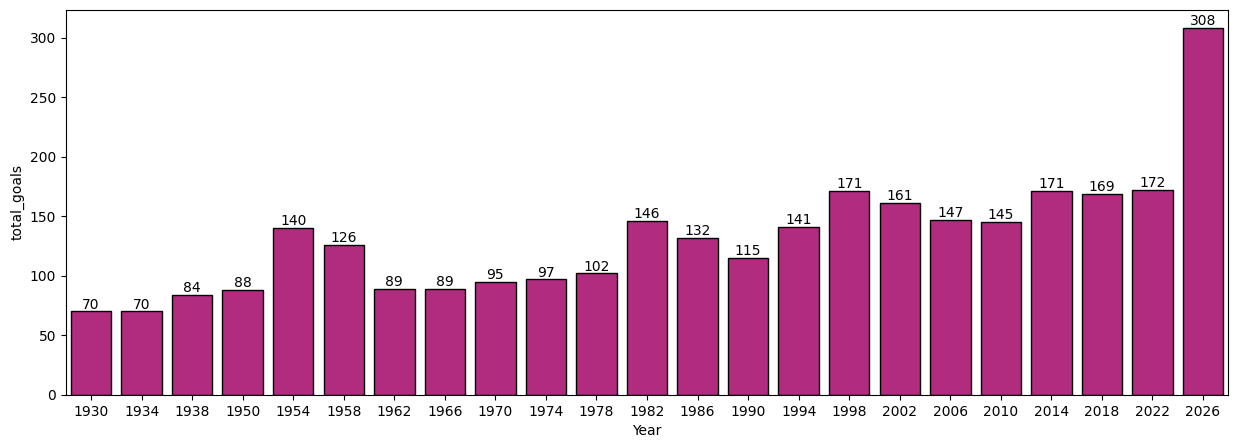

In [23]:
goals_per_WC = results[results['tournament'] == 'FIFA World Cup'].groupby(['Year'], as_index = False)['total_goals'].sum()

plt.figure(figsize = (15,5))
ax = sns.barplot(data = goals_per_WC, x = 'Year', y = 'total_goals', color = 'mediumvioletred', edgecolor = 'black')
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

#### Average goals scored in each FIFA World Cup

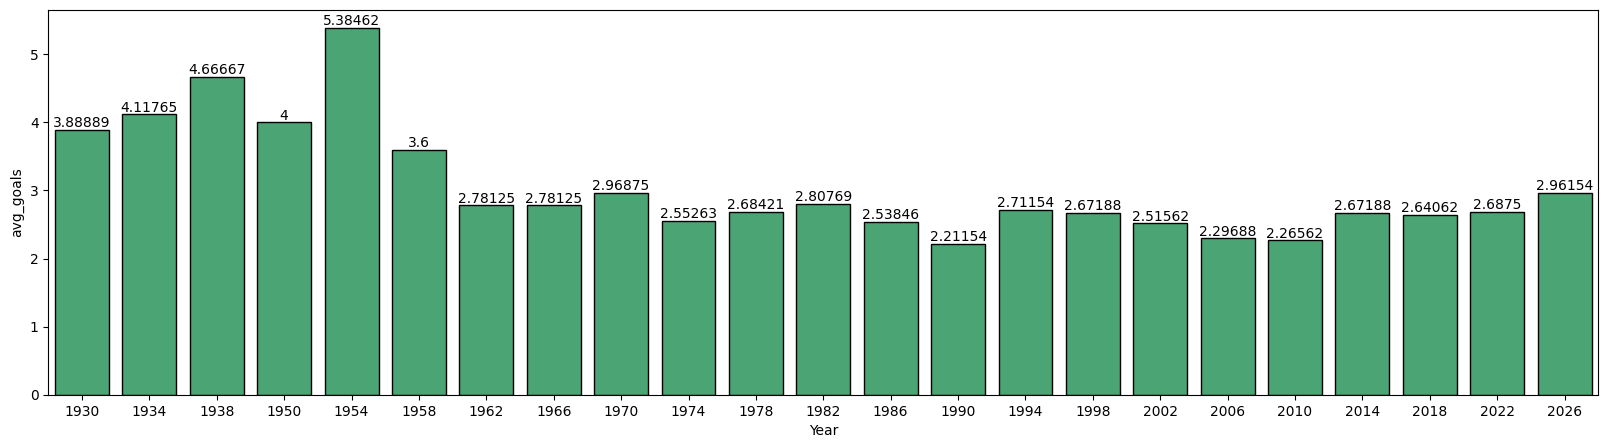

In [24]:
avg_goals_per_WC = results[results['tournament'] == 'FIFA World Cup'].groupby(['Year'], as_index = False)['total_goals'].mean()

plt.figure(figsize = (20,5))
ax = sns.barplot(data = avg_goals_per_WC, x = 'Year', y = 'total_goals', color = 'mediumseagreen', edgecolor = 'black')
for bars in ax.containers:
    ax.bar_label(bars)
plt.ylabel('avg_goals')
plt.show()

#### Most successful teams in FIFA World Cup - By Wins

In [25]:
# value_count() returns unique values and their frequency in desc order
wins_per_team = results[results['tournament'] == 'FIFA World Cup']['winner_team'].value_counts().head(15)
wins_per_team

Draw           238
Brazil          79
Germany         70
Argentina       54
Italy           45
France          45
Spain           38
England         38
Netherlands     32
Uruguay         25
Belgium         24
Mexico          21
Sweden          20
Russia          19
Portugal        19
Name: winner_team, dtype: int64

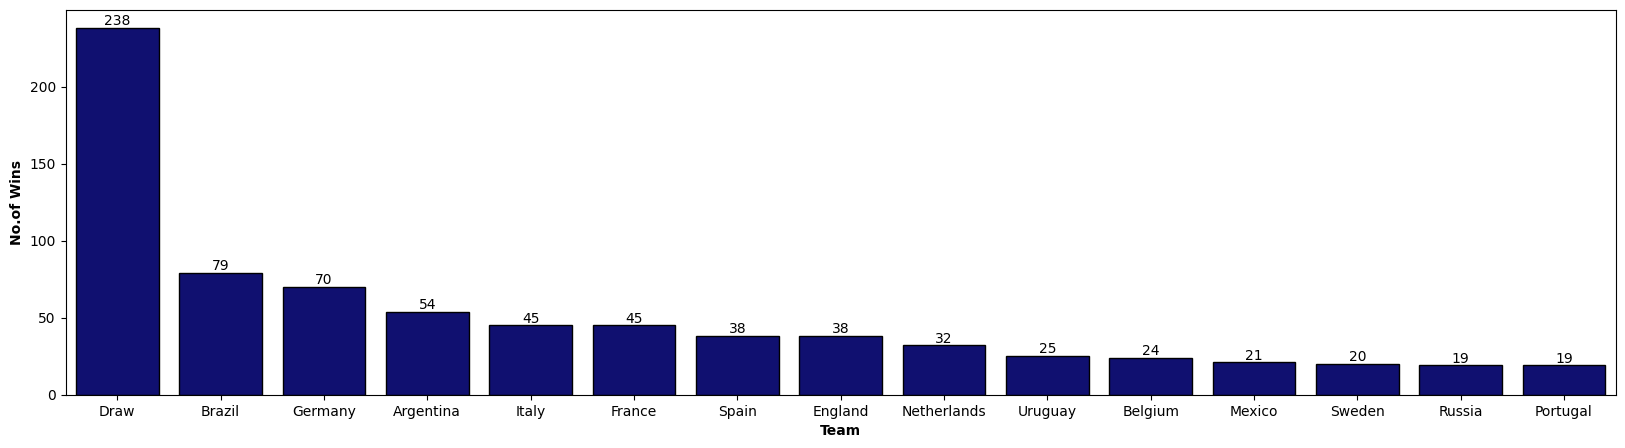

In [26]:
# Firstly we find top 15 most successful teams in desc order and then using 'order' parameter, we plot only those teams
top_order = wins_per_team.index

plt.figure(figsize = (20,5))
ax = sns.countplot(data = results[results['tournament'] == 'FIFA World Cup'], x = 'winner_team', order = top_order, color = 'navy', edgecolor = 'black')
for bars in ax.containers:
    ax.bar_label(bars)
plt.xlabel('Team', fontweight = 'bold')
plt.ylabel('No.of Wins', fontweight = 'bold')
plt.show()

#### Most successful teams in FIFA World Cup - By Trophies

In [27]:
finals_date = results[results['tournament'] == 'FIFA World Cup'].groupby(['Year'], as_index = False)['date'].max()
finals_date

,Year,date
0,1930,1930-07-30
1,1934,1934-06-10
2,1938,1938-06-19
3,1950,1950-07-16
4,1954,1954-07-04
5,1958,1958-06-29
6,1962,1962-06-17
7,1966,1966-07-30
8,1970,1970-06-21
9,1974,1974-07-07


In [28]:
# 'results' dataset with rows whose date is same as finals date
results[results['date'].isin(finals_date['date'])]

,date,home_team,away_team,home_score,away_score,tournament,city,country,is_neutral_venue,match_outcome,GD,total_goals,Month,Year,Decade,winner_team,matchup,scoreline,goals_by_winner
1509,1930-07-30,Uruguay,Argentina,4,2,FIFA World Cup,Montevideo,Uruguay,False,Home Win,2,6,7,1930,1930,Uruguay,Uruguay-Argentina,4-2,4
1894,1934-06-10,Italy,Czechoslovakia,2,1,FIFA World Cup,Rome,Italy,False,Home Win,1,3,6,1934,1930,Italy,Italy-Czechoslovakia,2-1,2
1895,1934-06-10,Lithuania,Latvia,2,0,Friendly,Kaunas,Lithuania,False,Home Win,2,2,6,1934,1930,Lithuania,Lithuania-Latvia,2-0,2
2349,1938-06-19,Brazil,Sweden,4,2,FIFA World Cup,Bordeaux,France,True,Home Win,2,6,6,1938,1930,Brazil,Brazil-Sweden,4-2,4
2350,1938-06-19,Hungary,Italy,2,4,FIFA World Cup,Colombes,France,True,Away Win,2,6,6,1938,1930,Italy,Hungary-Italy,2-4,4
3417,1950-07-16,Brazil,Uruguay,1,2,FIFA World Cup,Rio de Janeiro,Brazil,False,Away Win,1,3,7,1950,1950,Uruguay,Brazil-Uruguay,1-2,2
3418,1950-07-16,Spain,Sweden,1,3,FIFA World Cup,São Paulo,Brazil,True,Away Win,2,4,7,1950,1950,Sweden,Spain-Sweden,1-3,3
3419,1950-07-16,Zambia,Zimbabwe,3,2,Friendly,Kitwe,Northern Rhodesia,False,Home Win,1,5,7,1950,1950,Zambia,Zambia-Zimbabwe,3-2,3
3981,1954-07-04,Germany,Hungary,3,2,FIFA World Cup,Bern,Switzerland,True,Home Win,1,5,7,1954,1950,Germany,Germany-Hungary,3-2,3
3982,1954-07-04,Iceland,Norway,1,0,Friendly,Reykjavík,Iceland,False,Home Win,1,1,7,1954,1950,Iceland,Iceland-Norway,1-0,1


Since in some World Cups more than 1 match was conducted on final day, and there is no category stating whether it is a Final or Bronze-medal match, we cannot proceed further.\
In ideal case, using winner of that final day we would've counted no. of times each team had won finals i.e. trophies.\
sns.countplot(data = results[results['date'].isin(finals_date['date'])], x = 'winner_team')

#### Most successful teams in FIFA World Cup - By Goals Scored (in Victory)

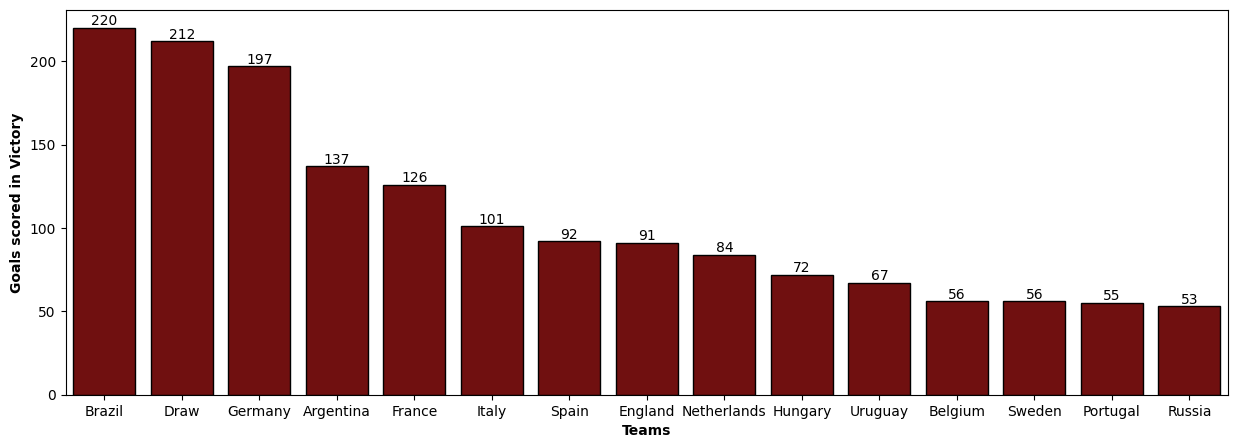

In [29]:
WC_victory_goals = results[results['tournament'] == 'FIFA World Cup'].groupby(['winner_team'], as_index = False)['goals_by_winner'].sum().sort_values('goals_by_winner', ascending = False).head(15)

plt.figure(figsize = (15,5))
ax = sns.barplot(data = WC_victory_goals, x = 'winner_team', y = 'goals_by_winner', color = 'maroon', edgecolor = 'black')
for bars in ax.containers:
    ax.bar_label(bars)
plt.xlabel('Teams', fontweight = 'bold')
plt.ylabel('Goals scored in Victory', fontweight = 'bold')
plt.show()

#### Average goals scored over deacdes 

In [30]:
results.groupby(['Decade'], as_index = False)['total_goals'].mean()

,Decade,total_goals
0,1870,4.538462
1,1880,5.581818
2,1890,5.152542
3,1900,4.159420
4,1910,4.218182
5,1920,3.884477
6,1930,4.318814
7,1940,4.344538
8,1950,4.004240
9,1960,3.478963


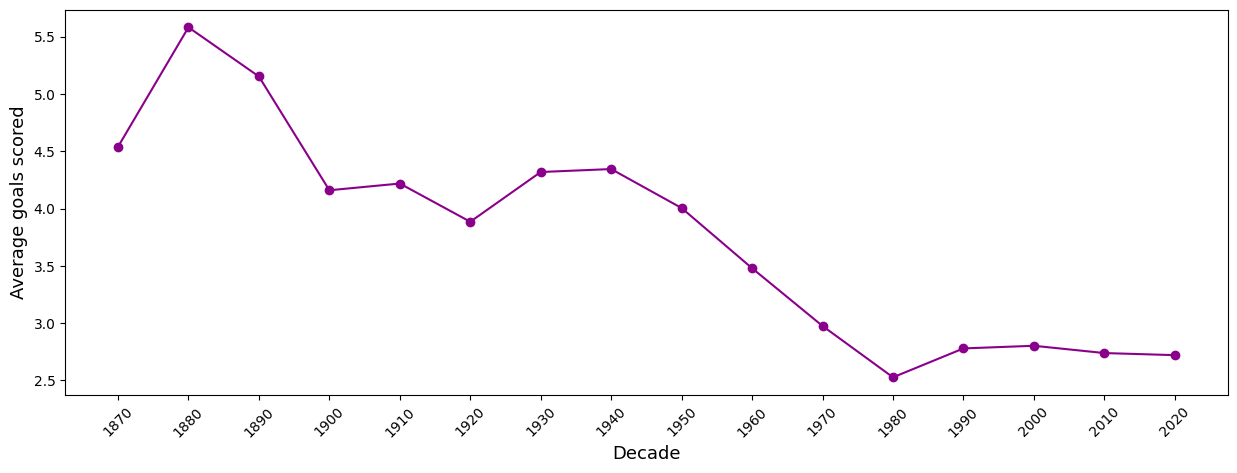

In [31]:
avg_goals_yr = results.groupby(['Decade'], as_index = False)['total_goals'].mean()

plt.figure(figsize = (15,5))
plt.plot(avg_goals_yr['Decade'], avg_goals_yr['total_goals'], marker = 'o', color = 'darkmagenta')
plt.xticks(avg_goals_yr['Decade'],rotation = 45)
plt.xlabel('Decade', fontsize = 13)
plt.ylabel('Average goals scored', fontsize = 13)
plt.show()

#### Home vs Away Wins

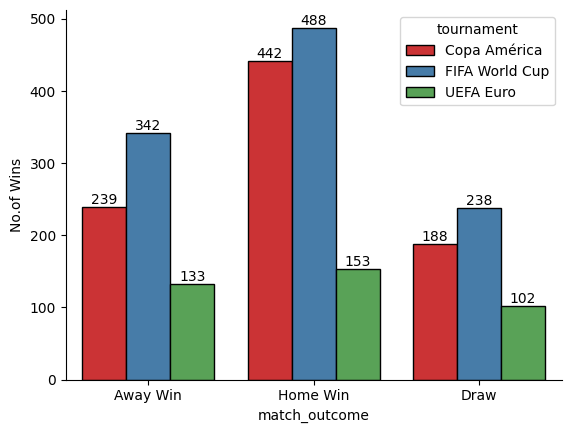

In [32]:
# creating dataset with only 3 tournaments and then plotting bars side by side using 'hue' parameter
tournaments = results[results['tournament'].isin(['FIFA World Cup', 'Copa América', 'UEFA Euro'])]

ax = sns.countplot(data = tournaments, x = 'match_outcome', hue = 'tournament', palette = 'Set1', edgecolor = 'black')
for bars in ax.containers:
    ax.bar_label(bars)
plt.ylabel('No.of Wins')
sns.despine()
plt.show()

#### Draw Percentage

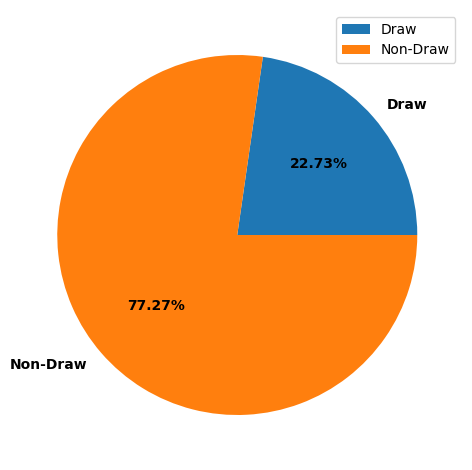

In [33]:
draw = (results['match_outcome'] == 'Draw').sum()
non_draw = (results['match_outcome'] != 'Draw').sum()

plt.pie([draw, non_draw],
       labels = ['Draw', 'Non-Draw'],
       autopct = '%.2f%%',
       textprops = {'color': 'black',
                   'fontweight': 'bold'})
plt.legend(loc = 'best')
plt.tight_layout()
plt.show()

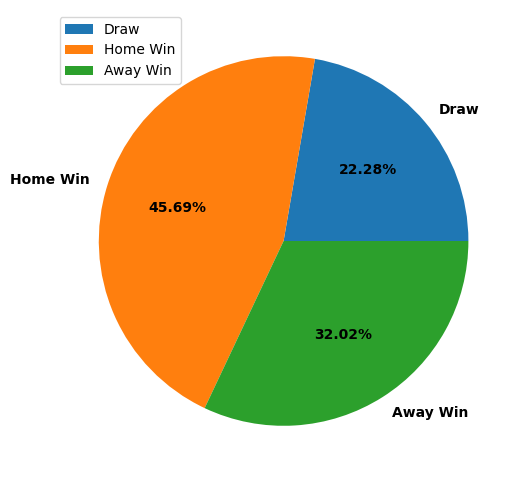

In [34]:
# Contribution of 'Draw', 'Home Win', 'Away Win' for FIFA World Cup
WC = results[results['tournament'].isin(['FIFA World Cup'])]

draw = (WC['match_outcome'] == 'Draw').sum()
home_win = (WC['match_outcome'] == 'Home Win').sum()
away_win = (WC['match_outcome'] == 'Away Win').sum()

plt.figure(figsize = (6,6))
plt.pie([draw, home_win, away_win],
       labels = ['Draw', 'Home Win', 'Away Win'],
       autopct = '%.2f%%',
       textprops = {'color': 'black',
                   'fontweight': 'bold'})
plt.legend(loc = 'upper left')
plt.show()

For FIFA World Cup, Copa América and UEFA Euro, most matches are won by Home team followed by Away team and then by draws. Thus home team advantage exists in World Cup.

#### Teams Won with highest Goal Difference

In [35]:
# For each winner_team finding max GD i.e. grouping by winner_team on basis of max of GD & then sorting by GD in desc order
results.groupby('winner_team', as_index = False)['GD'].max().sort_values('GD', ascending = False).head(15)

,winner_team,GD
17,Australia,31
271,Tahiti,30
97,Fiji,24
218,Provence,22
196,North Korea,21
221,Quebec,21
158,Libya,21
211,Papua New Guinea,20
150,Kuwait,20
269,Sápmi,20


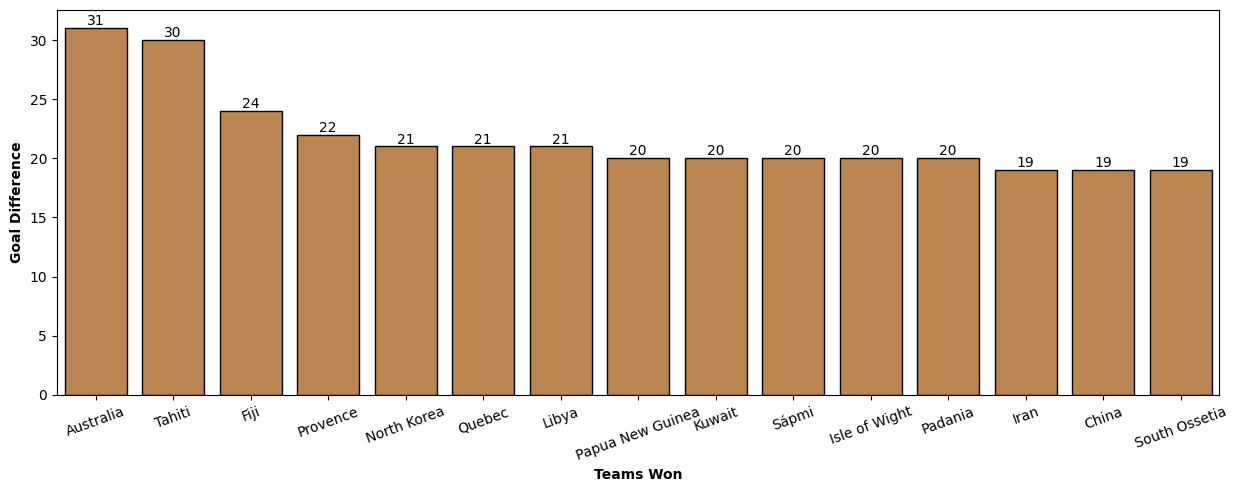

In [36]:
won_highest_GD = results.groupby('winner_team', as_index = False)['GD'].max().sort_values('GD', ascending = False).head(15)

plt.figure(figsize = (15,5))
ax = sns.barplot(x = won_highest_GD['winner_team'], y = won_highest_GD['GD'], color = 'peru', edgecolor = 'black')
for bars in ax.containers:
    ax.bar_label(bars)
plt.xticks(rotation = 20)
plt.xlabel('Teams Won', fontweight = 'bold')
plt.ylabel('Goal Difference', fontweight = 'bold')
plt.show()

#### Most common scoreline

In [37]:
# Finding 10 most common scorelines 
results['scoreline'].value_counts().head(15)

1-0    5107
1-1    4921
0-0    3974
2-0    3846
2-1    3781
0-1    3465
1-2    2558
3-0    2371
0-2    2232
2-2    1946
3-1    1913
4-0    1363
1-3    1096
0-3    1085
3-2     999
Name: scoreline, dtype: int64

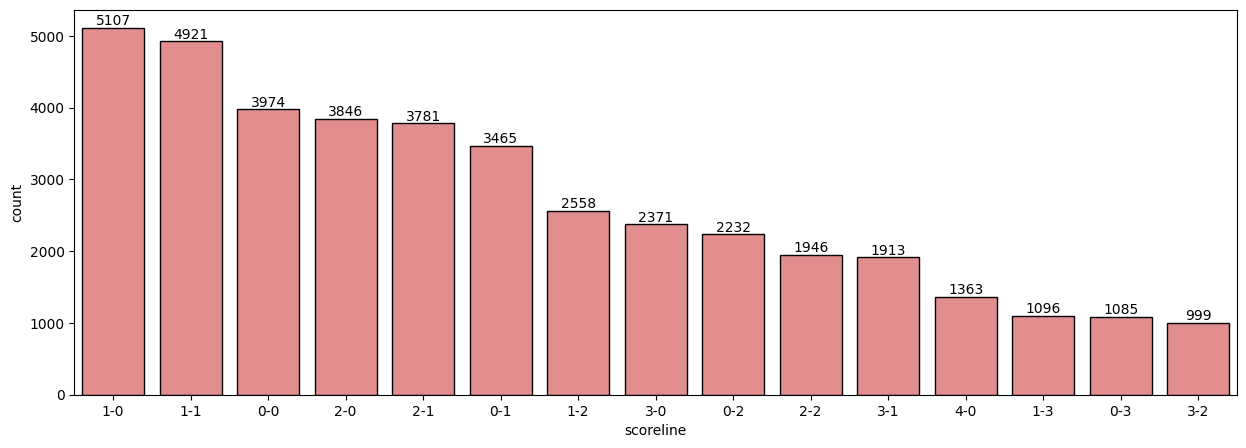

In [38]:
toporder = results['scoreline'].value_counts().head(15)

plt.figure(figsize = (15,5))
ax = sns.countplot(data = results, x = 'scoreline', order = toporder.index, color = 'lightcoral', edgecolor = 'black')
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

In [39]:
results.groupby(['tournament'], as_index = False)['total_goals'].sum().sort_values('total_goals', ascending = False).head(15)

,tournament,total_goals
94,Friendly,52849
89,FIFA World Cup qualification,25320
186,UEFA Euro qualification,7996
11,African Cup of Nations qualification,5625
88,FIFA World Cup,3028
2,AFC Asian Cup qualification,2728
54,Copa América,2726
33,CFU Caribbean Cup qualification,2125
10,African Cup of Nations,2009
129,Merdeka Tournament,1960


#### Goals Scored across tournaments

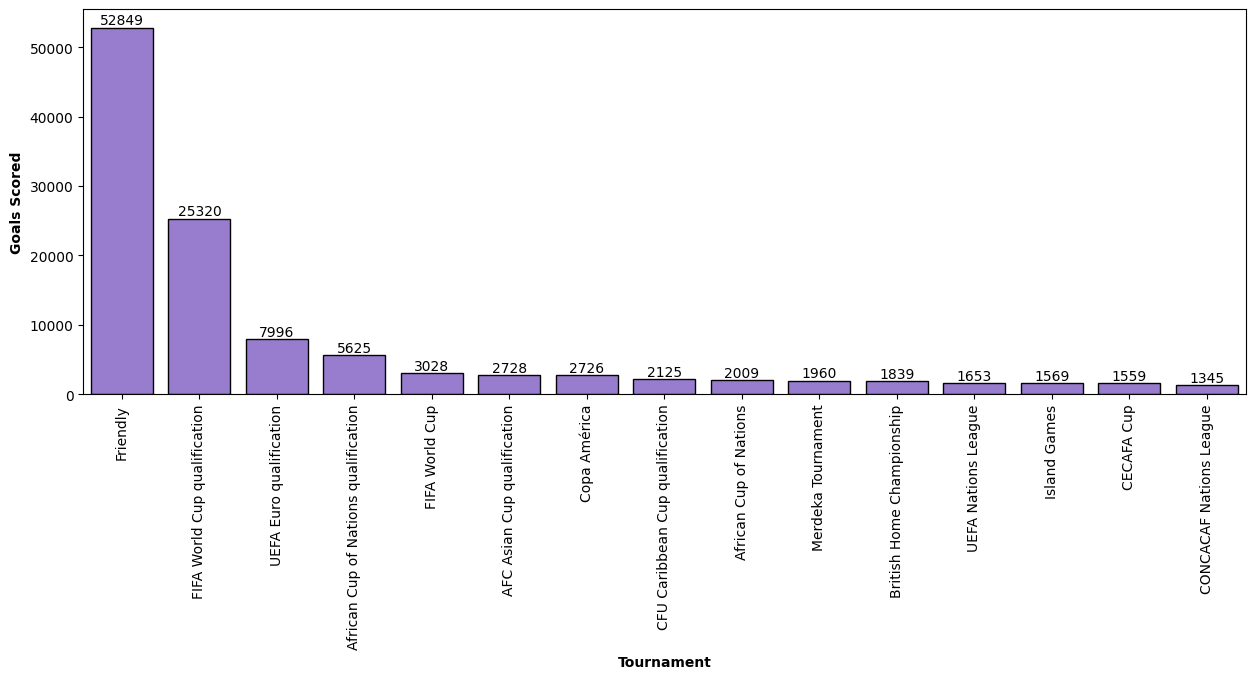

In [40]:
goals_per_tour = results.groupby(['tournament'], as_index = False)['total_goals'].sum().sort_values('total_goals', ascending = False).head(15)

plt.figure(figsize = (15,5))
ax = sns.barplot(x = goals_per_tour['tournament'], y = goals_per_tour['total_goals'], color = 'mediumpurple', edgecolor = 'black')
for bars in ax.containers:
    ax.bar_label(bars)
plt.xticks(rotation = 90)
plt.xlabel('Tournament', fontweight = 'bold')
plt.ylabel('Goals Scored', fontweight = 'bold')
plt.show()

### Insights & Analysis

* Excluding draw, Brazil have most World Cup wins (79) followed by Germany (70) and Argentina (54)
* 1-0 is the most common scoreline followed by 1-1 and 1-0
* For all tournaments combined, 22.73% of matches are draws and for FIFA World Cup, it is 22.28%
* For FIFA World Cup, home teams are more successful than away teams (45.69% & 32.02%)
* Most goals scored in FIFA World Cup was in 2026 edition (308) while fewest in 1930 and 1934 editions (70) 
* Average goals scored peaked in 1880s followed by sharp decline in every decade but have remained almost constant since 1990s
* Teams won with highest goal difference is Australia(31) followed by Tahiti(30) and Fiji(24)
* Most goals were scored in Friendlies followed by FIFA World Cup qualification and  UEFA Euro qualification

## former_names

### Data Cleaning & Manipulation

In [41]:
former_names.head()

,current,former,start_date,end_date
0,Benin,Dahomey,1959-11-08,1975-11-30
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10
3,Czechoslovakia,Bohemia,1903-04-05,1919-01-01
4,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01


In [42]:
former_names.shape

(36, 4)

In [43]:
former_names.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   current     36 non-null     object
 1   former      36 non-null     object
 2   start_date  36 non-null     object
 3   end_date    36 non-null     object
dtypes: object(4)
memory usage: 1.2+ KB


In [44]:
pd.isna(former_names).sum()

current       0
former        0
start_date    0
end_date      0
dtype: int64

In [45]:
former_names.duplicated().sum()

0

In [46]:
# checking datatypes for 'start_date' and 'end_date'
(type(former_names['start_date'][0]),
type(former_names['end_date'][0]))

(str, str)

In [47]:
# converting datatypes for both columns to datetime
former_names['start_date'] = pd.to_datetime(former_names['start_date'])
former_names['end_date'] = pd.to_datetime(former_names['end_date'])

(type(former_names['start_date'][0]), type(former_names['end_date'][0]))

(pandas._libs.tslibs.timestamps.Timestamp,
 pandas._libs.tslibs.timestamps.Timestamp)

In [48]:
# creating 'duration' column
former_names['duration'] = former_names['end_date'] - former_names['start_date']
former_names.head()

,current,former,start_date,end_date,duration
0,Benin,Dahomey,1959-11-08,1975-11-30,5866 days
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04,8878 days
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10,19579 days
3,Czechoslovakia,Bohemia,1903-04-05,1919-01-01,5750 days
4,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01,2312 days


In [49]:
# renaming columns
former_names.rename(columns = {'current': 'current_country_name', 'former': 'former_country_name'}, inplace = True)
former_names.tail()

,current_country_name,former_country_name,start_date,end_date,duration
31,Suriname,Dutch Guyana,1921-01-28,1975-11-25,20024 days
32,Tanzania,Tanganyika,1945-01-01,1964-04-26,7055 days
33,Vanuatu,New Hebrides,1951-10-04,1980-07-30,10527 days
34,Zambia,Northern Rhodesia,1947-02-22,1964-10-25,6455 days
35,Zimbabwe,Southern Rhodesia,1946-06-16,1980-04-18,12360 days


In [50]:
# creating new column by convering 'duration' column i.e. timedelta to int
former_names['days'] = former_names['duration'].dt.days
former_names.head()

,current_country_name,former_country_name,start_date,end_date,duration,days
0,Benin,Dahomey,1959-11-08,1975-11-30,5866 days,5866
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04,8878 days,8878
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10,19579 days,19579
3,Czechoslovakia,Bohemia,1903-04-05,1919-01-01,5750 days,5750
4,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01,2312 days,2312


In [51]:
type(former_names['days'][0])

numpy.int64

In [52]:
# creating 'decade' column which indicates decade of end_date i.e. decade in which name was changed
list_decade = []

for i in range(former_names.shape[0]):
    list_decade.append((int(former_names['end_date'][i].year/10))*10)        # int value of year/10 then multiplication by 10

former_names['decade'] = list_decade
former_names.head()

,current_country_name,former_country_name,start_date,end_date,duration,days,decade
0,Benin,Dahomey,1959-11-08,1975-11-30,5866 days,5866,1970
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04,8878 days,8878,1980
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10,19579 days,19579,2010
3,Czechoslovakia,Bohemia,1903-04-05,1919-01-01,5750 days,5750,1910
4,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01,2312 days,2312,1940


### EDA

#### Distribution of name change duration

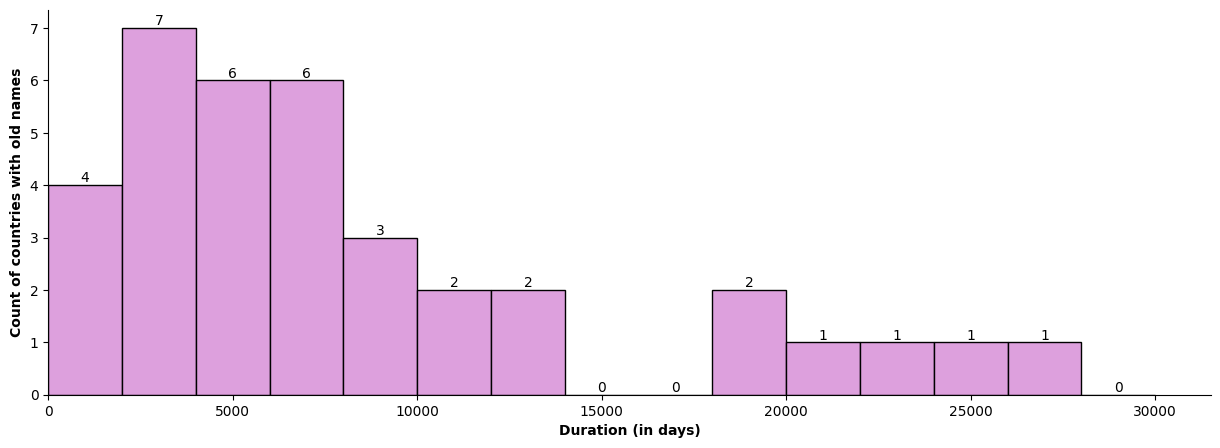

In [53]:
plt.figure(figsize = (15,5))
counts, bins, bars = plt.hist(former_names['days'], bins = 15, range = (0, 30000), color = 'plum', edgecolor = 'black')
plt.bar_label(bars)
plt.xlim(left = 0)
plt.xlabel('Duration (in days)', fontweight = 'bold')
plt.ylabel('Count of countries with old names', fontweight = 'bold')
sns.despine()
plt.show()

#### Teams with multiple name changes

In [54]:
former_names['current_country_name'].value_counts().head(10)

DR Congo               4
Czechoslovakia         3
Russia                 2
Republic of Ireland    2
Serbia                 2
Curaçao                1
Indonesia              1
Sri Lanka              1
Malawi                 1
Tanzania               1
Name: current_country_name, dtype: int64

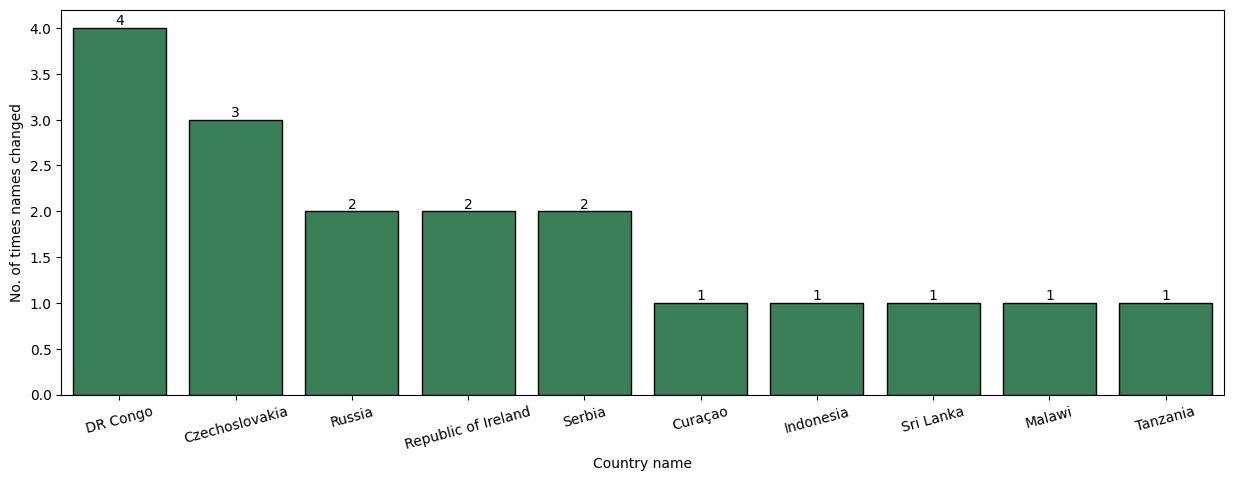

In [55]:
toporder = former_names['current_country_name'].value_counts().head(10)

plt.figure(figsize = (15,5))
ax = sns.countplot(data = former_names, x = 'current_country_name', order = toporder.index, color = 'seagreen', edgecolor = 'black')
for bars in ax.containers:
    ax.bar_label(bars)
plt.xticks(rotation = 15)
plt.xlabel('Country name')
plt.ylabel('No. of times names changed')
plt.show()

#### Name changes by decade

In [56]:
former_names['decade'].value_counts().sort_index()

1910    1
1930    1
1940    2
1950    5
1960    6
1970    7
1980    4
1990    5
2000    2
2010    3
Name: decade, dtype: int64

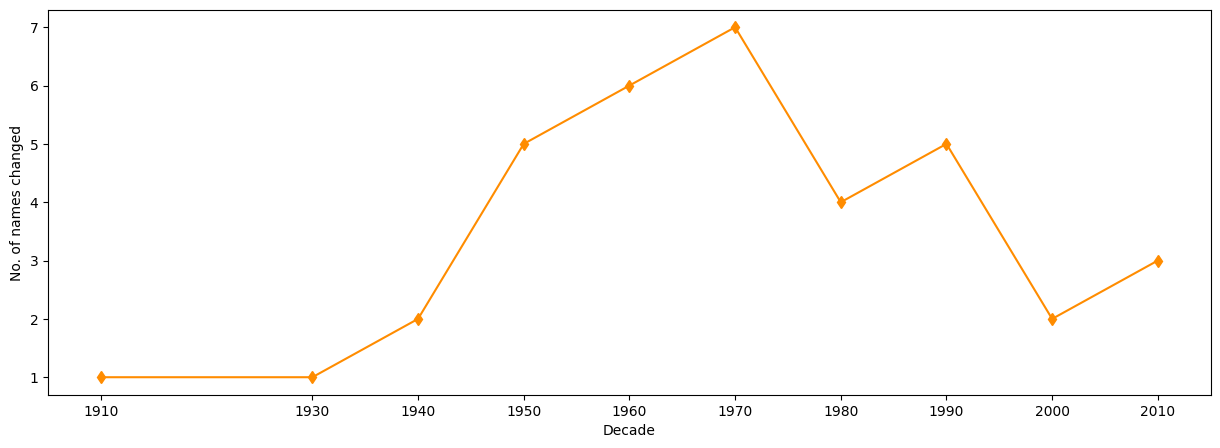

In [57]:
nameChanged_decade = former_names['decade'].value_counts().sort_index()

plt.figure(figsize = (15,5))
plt.plot(nameChanged_decade.index, nameChanged_decade.values, marker = 'd', color = 'darkorange')
plt.xticks(nameChanged_decade.index)
plt.xlabel('Decade')
plt.ylabel('No. of names changed')
plt.show()

### Insights & Analysis

* Most of the team names were changed within short to medium periods of time; although some team names remained in usage for much longer duration
* DR Congo team name was changed most no. of times (4) followed by Czechoslovaia (3) and Serbia, Republic of Ireland and Russia (2)
* The no. of team name changes steadily increased over decades untill it peaked in 1970s followed by sharp decline

## goalscorers

### Data Cleaning & Manipulation

In [58]:
goalscorers.head()

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False


In [59]:
goalscorers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47914 entries, 0 to 47913
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       47914 non-null  object 
 1   home_team  47914 non-null  object 
 2   away_team  47914 non-null  object 
 3   team       47914 non-null  object 
 4   scorer     47870 non-null  object 
 5   minute     47660 non-null  float64
 6   own_goal   47914 non-null  bool   
 7   penalty    47914 non-null  bool   
dtypes: bool(2), float64(1), object(5)
memory usage: 2.3+ MB


In [60]:
pd.isna(goalscorers).sum()

date           0
home_team      0
away_team      0
team           0
scorer        44
minute       254
own_goal       0
penalty        0
dtype: int64

In [61]:
# Dropping null values
goalscorers.dropna(inplace = True)

In [62]:
goalscorers.duplicated().sum()

10

In [63]:
goalscorers[goalscorers.duplicated()]

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
9345,1981-06-06,Fiji,Taiwan,Fiji,Ratu Jone,55.0,False,False
21015,2001-04-30,Oman,Laos,Oman,Hani Al-Dhabit,45.0,False,False
22149,2002-01-30,Burkina Faso,Ghana,Ghana,Isaac Boakye,90.0,False,False
23268,2003-12-03,Maldives,Mongolia,Maldives,Ibrahim Fazeel,45.0,False,False
24631,2004-10-09,Turkey,Kazakhstan,Turkey,Fatih Tekke,90.0,False,False
34443,2015-06-13,Poland,Georgia,Poland,Robert Lewandowski,90.0,False,False
38966,2019-09-08,Spain,Faroe Islands,Spain,Paco Alcácer,90.0,False,False
41302,2021-09-05,San Marino,Poland,Poland,Adam Buksa,90.0,False,False
41776,2021-10-12,Syria,Lebanon,Lebanon,Mohamad Kdouh,45.0,False,False
42833,2022-09-25,Moldova,Liechtenstein,Moldova,Victor Stînă,90.0,False,False


In [64]:
# Dropping duplicate values
goalscorers.drop_duplicates(inplace = True)

In [65]:
# converting 'date' datatype to datetime
goalscorers['date'] = pd.to_datetime(goalscorers['date'])
type(goalscorers['date'][0])

pandas._libs.tslibs.timestamps.Timestamp

In [66]:
# renaming columns
goalscorers.rename(columns = {'team':'scorer_team', 'own_goal':'is_own_goal', 'penalty':'is_penalty'}, inplace = True)
goalscorers.head(10)

,date,home_team,away_team,scorer_team,scorer,minute,is_own_goal,is_penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False
5,1916-07-06,Argentina,Chile,Chile,Telésforo Báez,44.0,False,False
6,1916-07-06,Argentina,Chile,Argentina,Juan Domingo Brown,60.0,False,True
7,1916-07-06,Argentina,Chile,Argentina,Juan Domingo Brown,62.0,False,True
8,1916-07-06,Argentina,Chile,Argentina,Alberto Marcovecchio,67.0,False,False
9,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,75.0,False,False


In [67]:
goalscorers['minute'].unique()

array([ 44.,  55.,  70.,  75.,   2.,  60.,  62.,  67.,  81.,  29.,  85.,
        10.,  23.,   8.,  58.,  77.,  20.,  15.,  39.,  56.,  80.,  76.,
        17.,  86.,  21.,  26.,  41.,  59.,  19.,  38.,  79.,  83.,  34.,
        31.,  43.,  22.,  57.,  65.,  13.,  33.,  63., 122.,  53.,  48.,
        30.,  40.,  73.,  37.,  27.,   9.,  66.,  46.,   1.,  71.,  14.,
        36.,   5.,  78.,   7.,  42.,  11.,  89.,  18.,  49.,  87.,  28.,
        88.,  64.,  74.,  82.,  84.,  50.,  68.,  51.,  35.,  61.,  25.,
        32.,  52.,  69.,   4.,  24.,  12., 104.,  47.,   6.,  72.,  16.,
         3.,  90.,  54.,  45.,  93., 109., 116.,  95., 102., 112., 118.,
       103., 105., 111.,  94., 114.,  91.,  97., 113., 101., 107., 110.,
        96., 120., 100., 108., 117.,  98.,  92., 115., 119., 106.,  99.])

In [68]:
goalscorers['is_own_goal'].unique()

array([False,  True])

In [69]:
goalscorers['is_penalty'].unique()

array([False,  True])

In [70]:
goalscorers['date'][0].year

1916

In [71]:
# creating 'Year' column
list_year1 = []
for i in range(goalscorers.shape[0]):
    list_year1.append(goalscorers['date'].iloc[i].year)

goalscorers['Year'] = list_year1
goalscorers.head()

,date,home_team,away_team,scorer_team,scorer,minute,is_own_goal,is_penalty,Year
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False,1916
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False,1916
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False,1916
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False,1916
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False,1916


In [72]:
type(goalscorers['Year'][0])

numpy.int64

In [73]:
# creating 'Decade' column
list_decade = []
for i in range(goalscorers.shape[0]):
    list_decade.append((int(goalscorers['Year'].iloc[i]/10)) * 10)
goalscorers['Decade'] = list_decade
goalscorers.head()

,date,home_team,away_team,scorer_team,scorer,minute,is_own_goal,is_penalty,Year,Decade
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False,1916,1910
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False,1916,1910
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False,1916,1910
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False,1916,1910
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False,1916,1910


### EDA

#### Top international goal scorers

In [74]:
goalscorers['scorer'].value_counts().head(20)

Cristiano Ronaldo      124
Harry Kane              75
Lionel Messi            71
Robert Lewandowski      68
Romelu Lukaku           67
Edin Džeko              58
Kylian Mbappé           55
Erling Haaland          53
Aleksandar Mitrović     52
Luis Suárez             51
Ali Daei                49
Miroslav Klose          48
Carlos Ruiz             47
Zlatan Ibrahimović      44
Robbie Keane            44
Memphis Depay           44
David Villa             41
Clint Dempsey           41
Andriy Shevchenko       40
Marko Arnautović        40
Name: scorer, dtype: int64

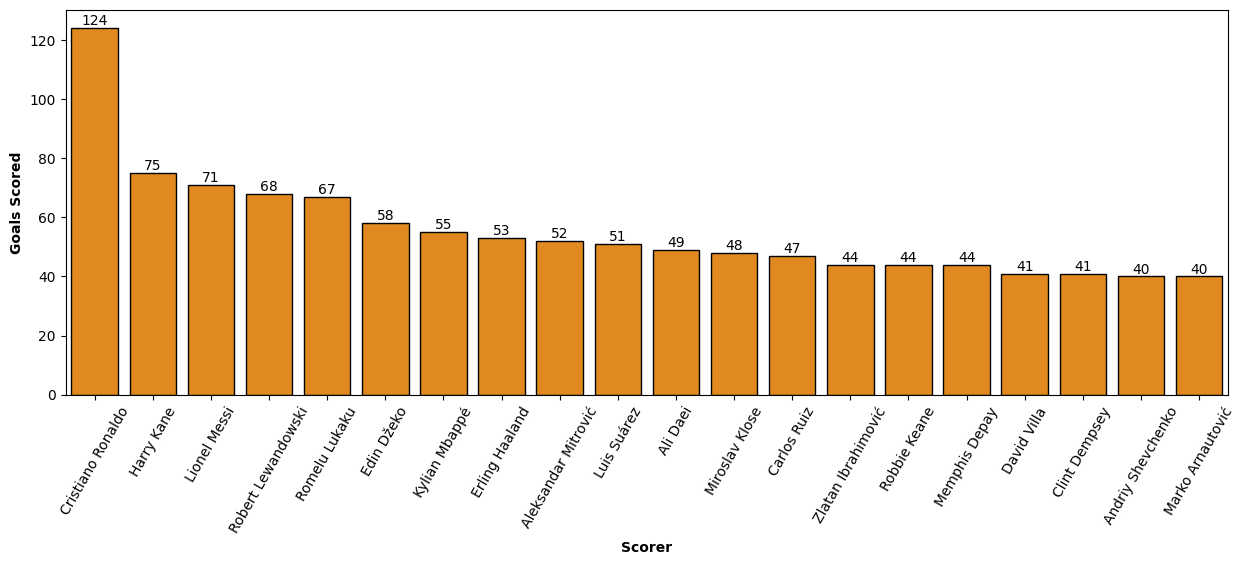

In [75]:
top_scorers = goalscorers['scorer'].value_counts().head(20)

plt.figure(figsize = (15,5))
ax = sns.countplot(data = goalscorers, x = 'scorer', order = top_scorers.index, color = 'darkorange', edgecolor = 'black')
for bars in ax.containers:
    ax.bar_label(bars)
plt.xticks(rotation = 60, fontsize = 10)
plt.xlabel('Scorer', fontweight = 'bold')
plt.ylabel('Goals Scored', fontweight = 'bold')
plt.show()

#### Most Non-Penalty goals scored

In [76]:
goalscorers[goalscorers['is_penalty'] == False]['scorer'].value_counts().head(15)

Cristiano Ronaldo      102
Romelu Lukaku           60
Lionel Messi            57
Edin Džeko              56
Robert Lewandowski      54
Harry Kane              51
Aleksandar Mitrović     48
Miroslav Klose          48
Erling Haaland          48
Kylian Mbappé           44
Carlos Ruiz             43
Luis Suárez             42
Ali Daei                41
Zlatan Ibrahimović      39
Sardar Azmoun           37
Name: scorer, dtype: int64

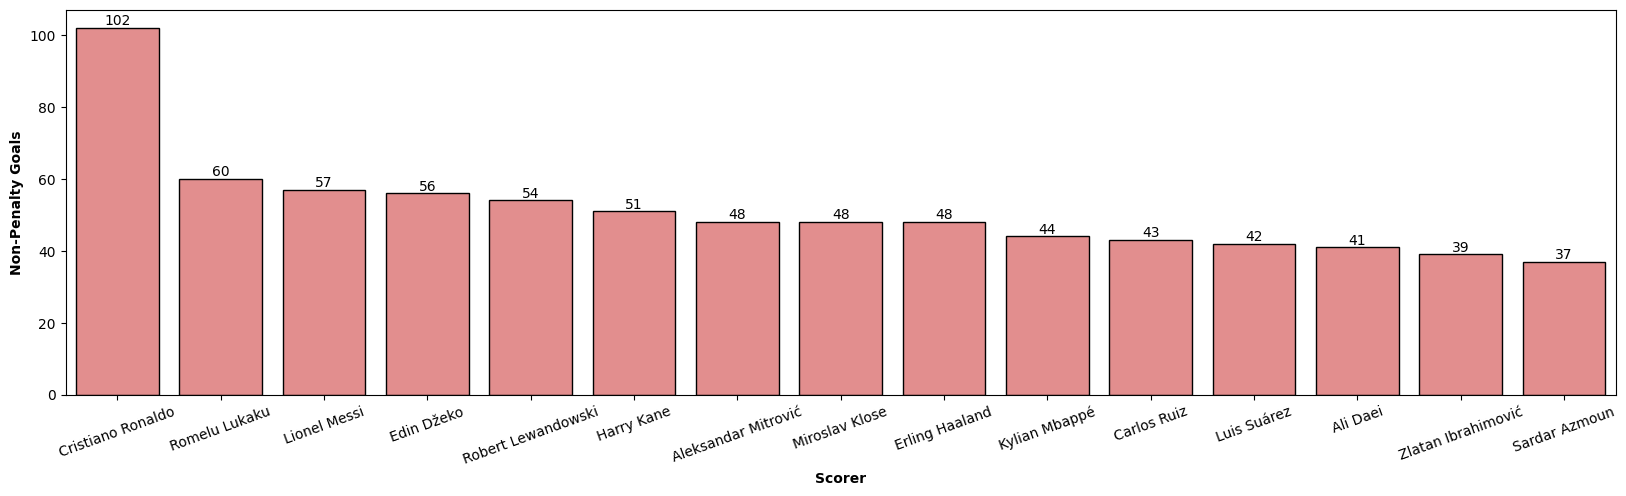

In [77]:
non_pen_goals = goalscorers[goalscorers['is_penalty'] == False]['scorer'].value_counts().head(15)

plt.figure(figsize = (20,5))
ay = sns.countplot(data = goalscorers[goalscorers['is_penalty'] == False], x = 'scorer', order = non_pen_goals.index, color = 'lightcoral', edgecolor = 'black')
for bars in ay.containers:
    ay.bar_label(bars)
plt.xticks(rotation = 20)
plt.xlabel('Scorer', fontweight = 'bold')
plt.ylabel('Non-Penalty Goals', fontweight = 'bold')
plt.show()

#### Goals by Team

In [78]:
goalscorers['scorer_team'].value_counts().head(15)

Brazil         1085
Germany        1025
Argentina       998
Spain           953
Netherlands     907
Mexico          872
England         833
Uruguay         829
France          822
Italy           761
Portugal        756
Belgium         738
Sweden          669
Russia          644
Australia       632
Name: scorer_team, dtype: int64

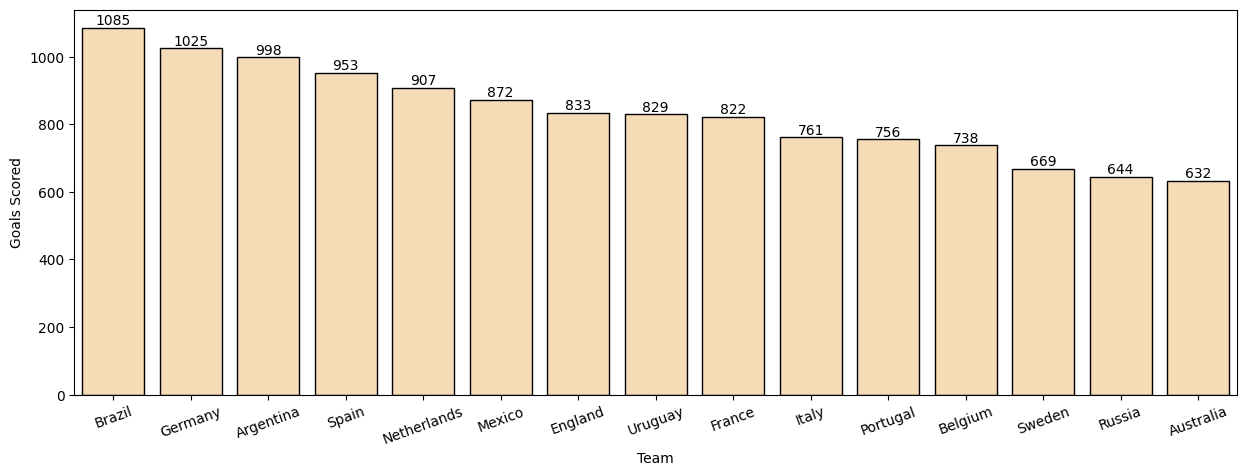

In [79]:
goals_team = goalscorers['scorer_team'].value_counts().head(15)

plt.figure(figsize = (15,5))
ax = sns.countplot(data = goalscorers, x = 'scorer_team', order = goals_team.index, color = 'navajowhite',  edgecolor = 'black')
for bars in ax.containers:
    ax.bar_label(bars)
plt.xticks(rotation = 20)
plt.xlabel('Team')
plt.ylabel('Goals Scored')
plt.show()

#### Team with most penalties awarded

In [80]:
goalscorers[goalscorers['is_penalty'] == True]['scorer_team'].value_counts().head(15)

Brazil         69
Mexico         67
England        67
Netherlands    67
Spain          60
Germany        60
Argentina      59
France         55
Sweden         54
Italy          52
Denmark        52
Belgium        51
Uruguay        48
Austria        48
Portugal       44
Name: scorer_team, dtype: int64

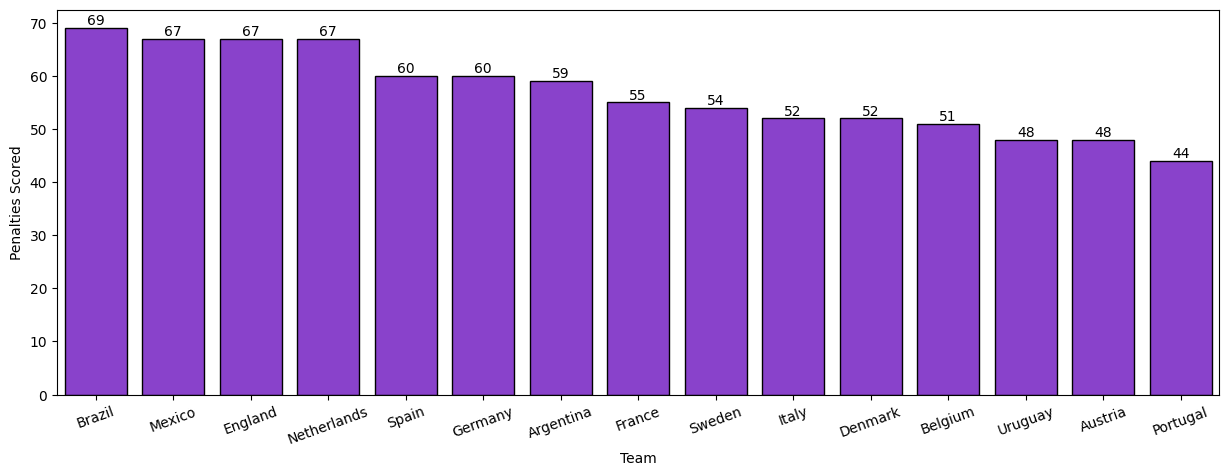

In [81]:
pen_team = goalscorers[goalscorers['is_penalty'] == True]['scorer_team'].value_counts().head(15)

plt.figure(figsize = (15,5))
ax = sns.countplot(data = goalscorers[goalscorers['is_penalty'] == True], x = 'scorer_team', order = pen_team.index, color = 'blueviolet', edgecolor = 'black')
for bars in ax.containers:
    ax.bar_label(bars)
plt.xticks(rotation = 20)
plt.xlabel('Team')
plt.ylabel('Penalties Scored')
plt.show()

#### Goal distribution by minutes 

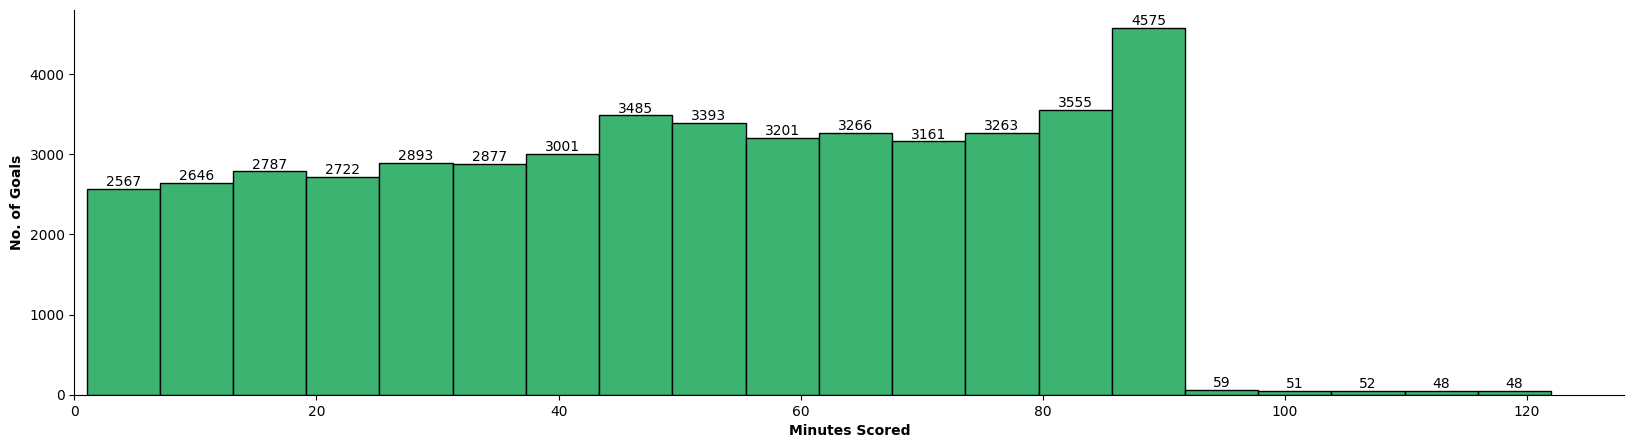

In [82]:
plt.figure(figsize = (20,5))
counts, bins, bars = plt.hist(goalscorers['minute'], bins = 20, color = 'mediumseagreen', edgecolor = 'black')
plt.bar_label(bars)
plt.xlim(left=0)
plt.xlabel('Minutes Scored', fontweight = 'bold')
plt.ylabel('No. of Goals', fontweight = 'bold')
sns.despine()
plt.show()

#### Distribution of Own Goals & Penalties Scored

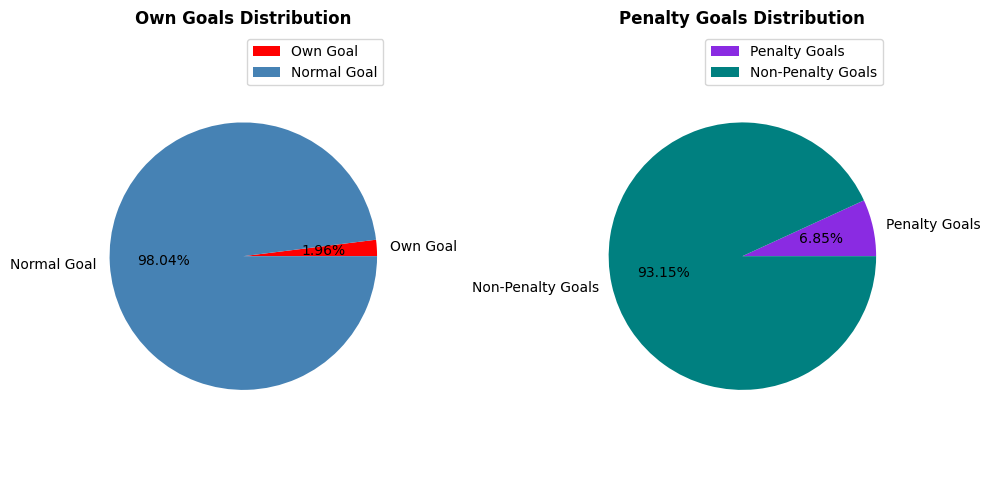

In [83]:
own_goals = (goalscorers['is_own_goal'] == True).sum()
normal_goals = (goalscorers['is_own_goal'] == False).sum()
pen_goals = (goalscorers['is_penalty'] == True).sum()
nonpen_goals = (goalscorers['is_penalty'] == False).sum()

color_list = ['red', 'steelblue']            # colors for both pie charts
color_list1 = ['blueviolet', 'teal']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))     # Create subplots: 1 row, 2 columns

axes[0].pie([own_goals, normal_goals],              # First Pie Chart i.e. Own Goals Distribution
       labels = ['Own Goal', 'Normal Goal'],
       autopct = '%.2f%%',
       colors = color_list)
axes[0].set_title('Own Goals Distribution', fontweight = 'bold')
axes[0].legend(loc = 'upper right')

axes[1].pie([pen_goals, nonpen_goals],              # Second Pie Chart i.e. Penalty Goals Distribution
       labels = ['Penalty Goals', 'Non-Penalty Goals'],
       autopct = '%.2f%%',
       colors = color_list1)
axes[1].set_title('Penalty Goals Distribution', fontweight = 'bold')
axes[1].legend(loc = 'upper right')

for ax in axes:                  # Equal aspect ratio ensures pie is drawn as a circle
    ax.axis('equal')

plt.tight_layout()               # Adjust layout so legends don't overlap
plt.show()

#### Goals by Year

In [84]:
goalscorers['Year'].value_counts().sort_index()

1916      18
1917      21
1919      27
1920      16
1921      14
        ... 
2022     922
2023    1130
2024    1649
2025    1678
2026     393
Name: Year, Length: 104, dtype: int64

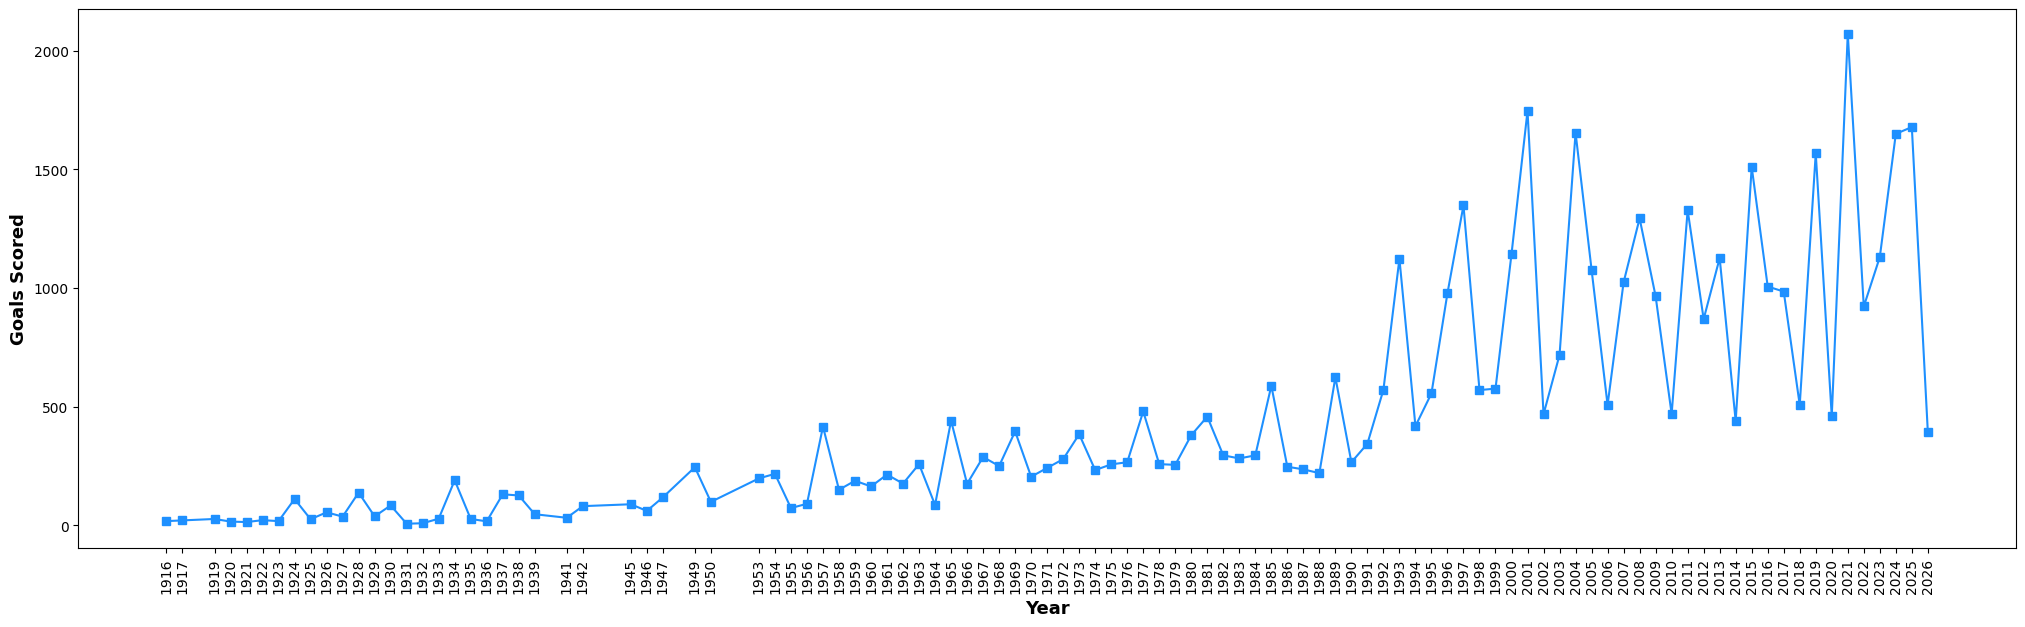

In [85]:
goals_yr = goalscorers['Year'].value_counts().sort_index()

plt.figure(figsize = (25,7))
plt.plot(goals_yr.index, goals_yr.values, marker = 's',color = 'dodgerblue')
plt.xticks(goals_yr.index, rotation = 90)
plt.xlabel('Year', fontsize = 13, fontweight = 'bold')
plt.ylabel('Goals Scored', fontsize = 13, fontweight = 'bold')
plt.show()

#### Goals by Decade

In [86]:
goalscorers['Decade'].value_counts().sort_index()

1910       66
1920      475
1930      666
1940      626
1950     1432
1960     2448
1970     2859
1980     3625
1990     6750
2000    10595
2010     9806
2020     8302
Name: Decade, dtype: int64

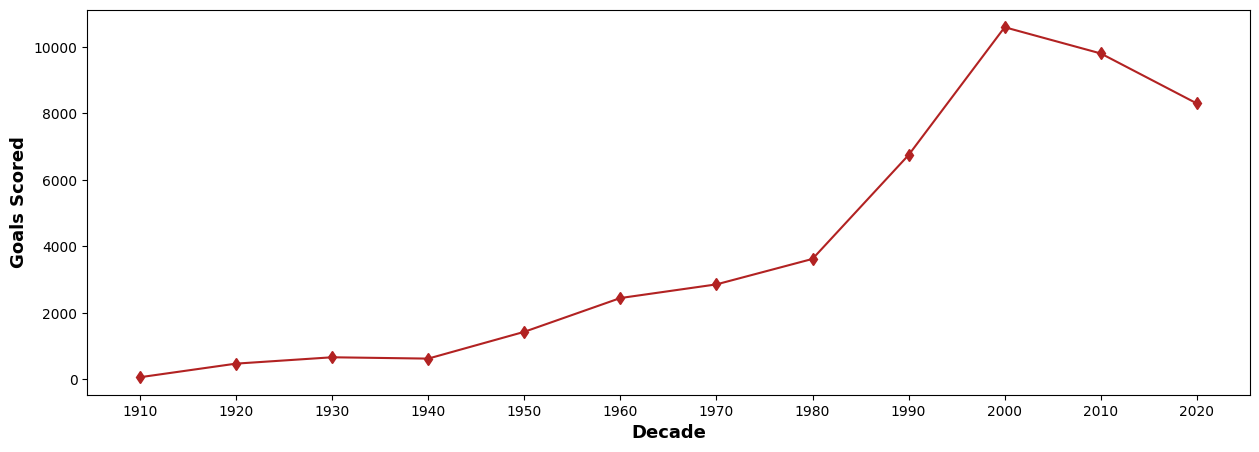

In [87]:
goals_decade = goalscorers['Decade'].value_counts().sort_index()

plt.figure(figsize = (15,5))
plt.plot(goals_decade.index, goals_decade.values, marker = 'd', color = 'firebrick')
plt.xticks(goals_decade.index)
plt.xlabel('Decade', fontsize = 13, fontweight = 'bold')
plt.ylabel('Goals Scored', fontsize = 13, fontweight = 'bold')
plt.show()

### Insights & Analysis

* Top international goalscorer is Cristiano Ronaldo (124) followed by Harry Kane (75) and Lionel Messi (71)
* Brazil has scored the most goals (1085) followed by Germany (1025) and Argentina (998)
* Goals have been scored almost evenly across first 90 minutes with little peak in range of 84-90 minutes
* Out of the total goals scored, only 6.85% were penalty goals.
* Total of 1.96% of total goals scored were own goals.
* Goals scored has increased steadily over time. It peaked in 2000s followed by a slight decline

## shootouts

### Data Cleaning & Manipulation

In [88]:
shootouts.head()

,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,NaN
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN
2,1972-05-07,South Korea,Iraq,Iraq,NaN
3,1972-05-17,Thailand,South Korea,South Korea,NaN
4,1972-05-19,Thailand,Cambodia,Thailand,NaN


In [89]:
shootouts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date           683 non-null    object
 1   home_team      683 non-null    object
 2   away_team      683 non-null    object
 3   winner         683 non-null    object
 4   first_shooter  260 non-null    object
dtypes: object(5)
memory usage: 26.8+ KB


In [90]:
pd.isna(shootouts).sum()

date               0
home_team          0
away_team          0
winner             0
first_shooter    423
dtype: int64

In [91]:
# we cannot drop 423/683 rows as it'll lead to loss of major chunck of data, so we replace it with 'NA'
shootouts.fillna('NA', inplace = True)

In [92]:
shootouts.duplicated().sum()

0

In [93]:
# converting 'date' datatype to datetime
shootouts['date'] = pd.to_datetime(shootouts['date'])
type(shootouts['date'][0])

pandas._libs.tslibs.timestamps.Timestamp

In [94]:
# creating 'matchup' column 
shootouts['matchup'] = shootouts['home_team'] + '-' + shootouts['away_team']
shootouts.head()

,date,home_team,away_team,winner,first_shooter,matchup
0,1967-08-22,India,Taiwan,Taiwan,NA,India-Taiwan
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NA,South Korea-Vietnam Republic
2,1972-05-07,South Korea,Iraq,Iraq,NA,South Korea-Iraq
3,1972-05-17,Thailand,South Korea,South Korea,NA,Thailand-South Korea
4,1972-05-19,Thailand,Cambodia,Thailand,NA,Thailand-Cambodia


In [95]:
# creating new column 'is_home_team_winner'
shootouts['is_home_team_winner'] = (shootouts['home_team'] == shootouts['winner'])
shootouts.head()

,date,home_team,away_team,winner,first_shooter,matchup,is_home_team_winner
0,1967-08-22,India,Taiwan,Taiwan,NA,India-Taiwan,False
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NA,South Korea-Vietnam Republic,True
2,1972-05-07,South Korea,Iraq,Iraq,NA,South Korea-Iraq,False
3,1972-05-17,Thailand,South Korea,South Korea,NA,Thailand-South Korea,False
4,1972-05-19,Thailand,Cambodia,Thailand,NA,Thailand-Cambodia,True


In [96]:
# Extracting 'Year' and 'Decade' from 'date' column
list_year = []
for i in range(shootouts.shape[0]): 
    list_year.append(shootouts['date'][i].year)
shootouts['Year'] = list_year

list_decade = []
for i in range(shootouts.shape[0]):
    list_decade.append(int(shootouts['date'][i].year/10) * 10)
shootouts['Decade'] = list_decade

shootouts.head()

,date,home_team,away_team,winner,first_shooter,matchup,is_home_team_winner,Year,Decade
0,1967-08-22,India,Taiwan,Taiwan,NA,India-Taiwan,False,1967,1960
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NA,South Korea-Vietnam Republic,True,1971,1970
2,1972-05-07,South Korea,Iraq,Iraq,NA,South Korea-Iraq,False,1972,1970
3,1972-05-17,Thailand,South Korea,South Korea,NA,Thailand-South Korea,False,1972,1970
4,1972-05-19,Thailand,Cambodia,Thailand,NA,Thailand-Cambodia,True,1972,1970


### EDA

#### Most Shootout Wins

In [97]:
shootouts['winner'].value_counts().head(15)

Egypt           16
Argentina       15
South Korea     15
Zambia          14
Thailand        13
South Africa    13
Iraq            11
Senegal         11
Kenya           10
Iran            10
Indonesia       10
Ivory Coast     10
Nigeria         10
Brazil           9
Cameroon         9
Name: winner, dtype: int64

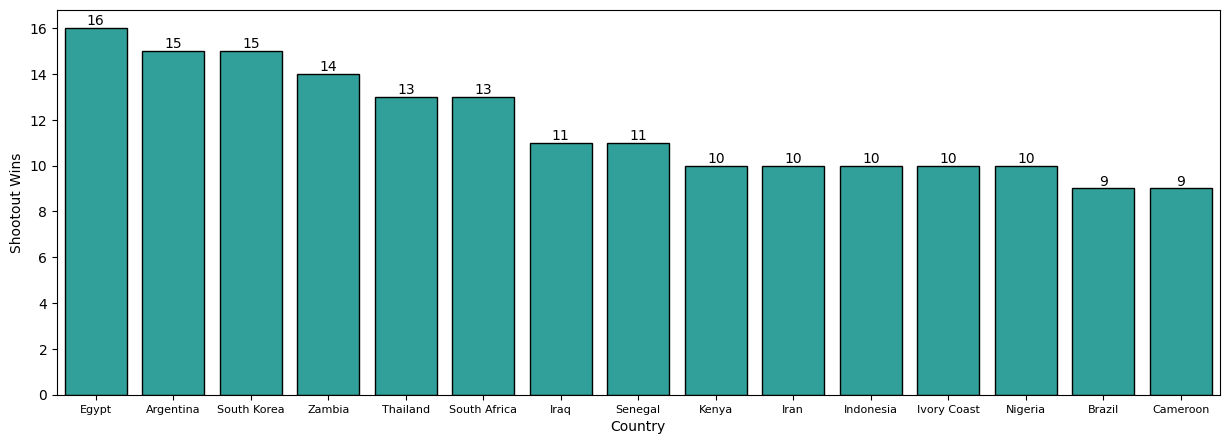

In [98]:
shootout_wins = shootouts['winner'].value_counts().head(15)

plt.figure(figsize = (15,5))
ax = sns.countplot(data = shootouts, x = 'winner', order = shootout_wins.index, color = 'lightseagreen', edgecolor = 'black')
for bars in ax.containers:
    ax.bar_label(bars)
plt.xticks(fontsize = 8)
plt.xlabel('Country')
plt.ylabel('Shootout Wins')
plt.show()

#### Shootouts over Year

In [99]:
shootouts['Year'].value_counts().sort_index()

1967     1
1971     1
1972     3
1973    11
1974     6
1975     4
1976     2
1977     5
1979     6
1980     6
1981     3
1982     8
1983    10
1984    16
1985    11
1986    11
1987    11
1988    14
1989     7
1990    13
1991    12
1992     8
1993    13
1994     6
1995    18
1996    17
1997     8
1998    17
1999    14
2000    21
2001    13
2002    24
2003    14
2004    22
2005    15
2006    14
2007    13
2008     5
2009     3
2010     9
2011    15
2012    11
2013     8
2014    12
2015    17
2016    23
2017    13
2018    18
2019    27
2020     4
2021    17
2022    26
2023    18
2024    24
2025    16
2026    19
Name: Year, dtype: int64

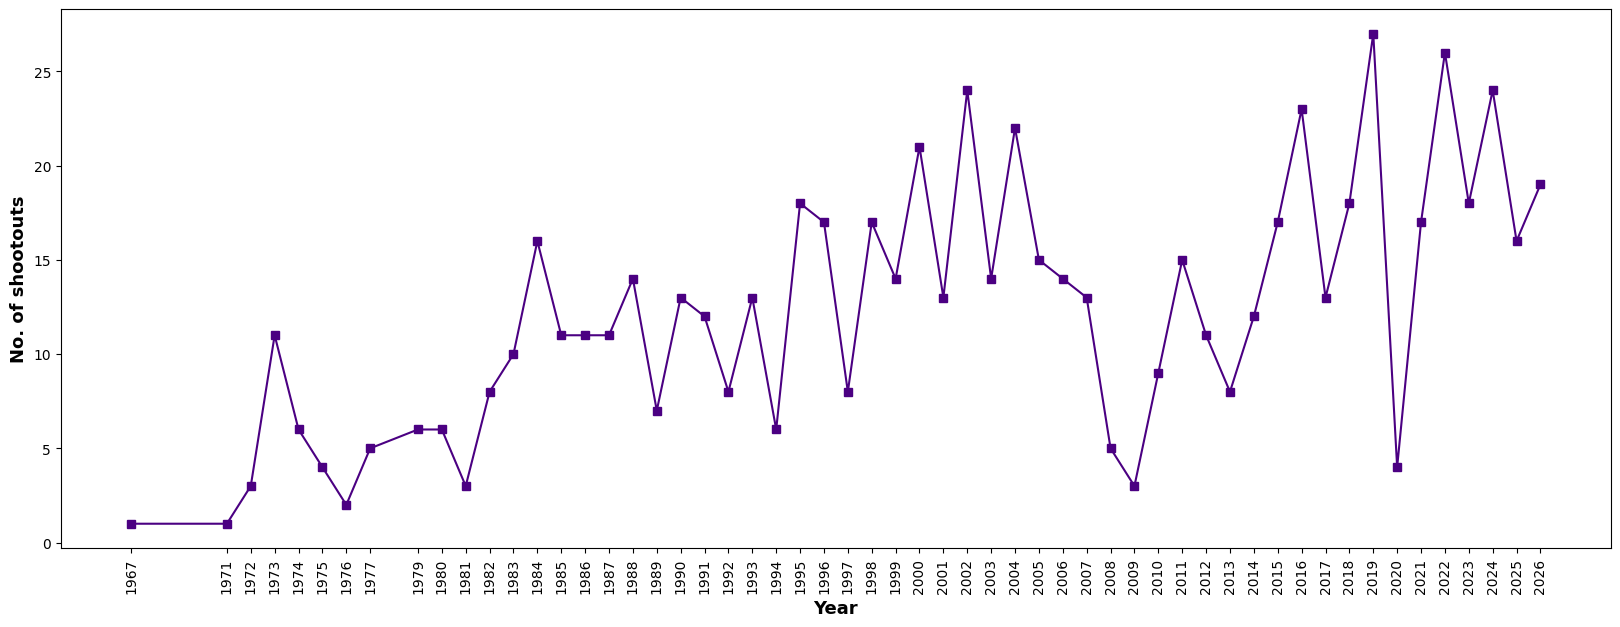

In [100]:
yearwise_shootouts = shootouts['Year'].value_counts().sort_index()

plt.figure(figsize = (20,7))
plt.plot(yearwise_shootouts.index, yearwise_shootouts.values, marker = 's', color = 'indigo')
plt.xticks(yearwise_shootouts.index, rotation = 90)
plt.xlabel('Year', fontsize = 13, fontweight = 'bold')
plt.ylabel('No. of shootouts', fontsize = 13, fontweight = 'bold')
plt.show()

#### Shootouts over Decade

In [101]:
shootouts['Decade'].value_counts().sort_index()

1960      1
1970     38
1980     97
1990    126
2000    144
2010    153
2020    124
Name: Decade, dtype: int64

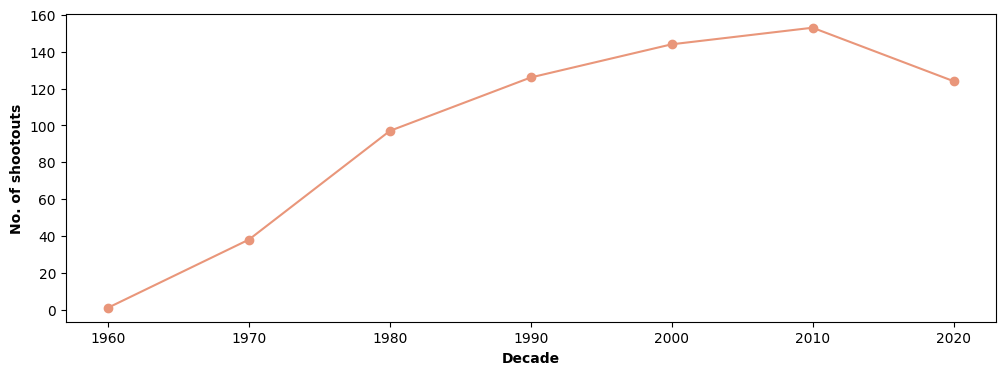

In [102]:
decadewise_shootouts = shootouts['Decade'].value_counts().sort_index()

plt.figure(figsize = (12,4))
plt.plot(decadewise_shootouts.index, decadewise_shootouts.values, marker = 'o', color = 'darksalmon')
plt.xticks(decadewise_shootouts.index, rotation = 0)
plt.xlabel('Decade', fontweight = 'bold')
plt.ylabel('No. of shootouts', fontweight = 'bold')
plt.show()

#### Most shootout appearences

In [103]:
# combining both home and away teams
total_teams = pd.concat((shootouts['home_team'], shootouts['away_team']))
total_teams

0               India
1         South Korea
2         South Korea
3            Thailand
4            Thailand
            ...      
678    Rouet-Provence
679          Paraguay
680           Morocco
681             Egypt
682          Colombia
Length: 1366, dtype: object

In [104]:
total_teams.value_counts().head(15)

South Africa    28
Egypt           27
Zambia          25
South Korea     25
Argentina       23
Iran            23
Thailand        22
Senegal         21
Ivory Coast     18
Malawi          18
Cameroon        18
Uganda          18
Mali            18
Nigeria         17
Uruguay         17
dtype: int64

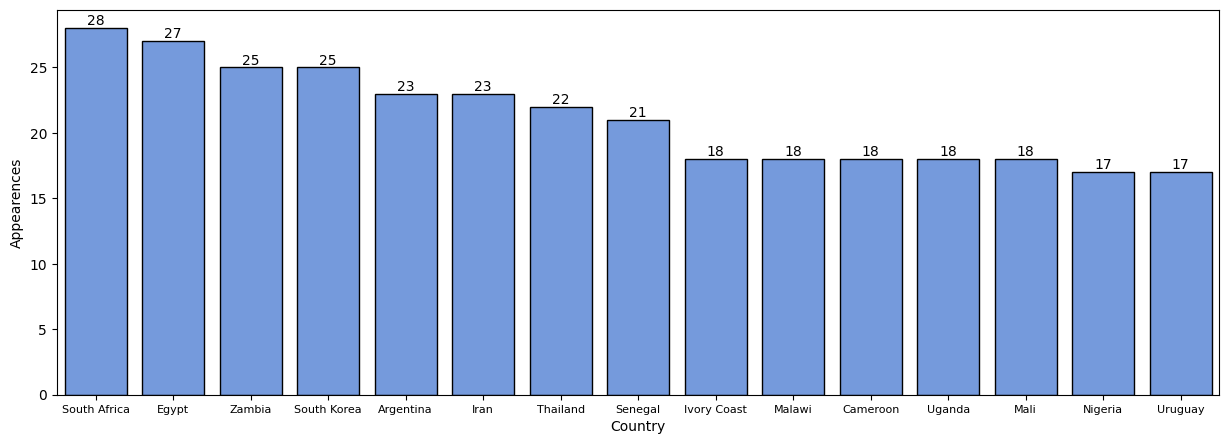

In [105]:
country_shootouts = total_teams.value_counts().head(15)

plt.figure(figsize = (15,5))
ax = sns.barplot(x = country_shootouts.index, y = country_shootouts.values, color = 'cornflowerblue', edgecolor = 'black')
for bars in ax.containers:
    ax.bar_label(bars)
plt.xticks(fontsize = 8)
plt.xlabel('Country')
plt.ylabel('Appearences')
plt.show()

#### Home vs Away Shootout Wins

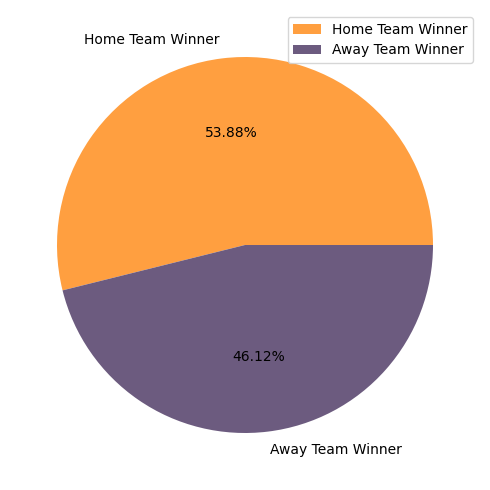

In [106]:
home_wins = (shootouts['is_home_team_winner'] == True).sum()
away_wins = (shootouts['is_home_team_winner'] == False).sum()

colors_list = ['#FF9F40', '#6C5B7F']
plt.figure(figsize = (5,5))
plt.pie([home_wins, away_wins],
       labels = ['Home Team Winner', 'Away Team Winner'],
       autopct = '%.2f%%',
       colors = colors_list,
       textprops = {'color': 'black'})
plt.legend()
plt.tight_layout()
plt.show()

This shows their is advantage for home teams during Shootouts over away teams

#### Most common shootout matchups

In [107]:
shootouts['matchup'].value_counts().head(15)

Indonesia-Thailand      5
Kenya-Uganda            4
Uruguay-Brazil          4
Brazil-Paraguay         3
Guernsey-Jersey         3
Japan-South Korea       3
Mali-Guinea             3
United States-Panama    3
Thailand-Malaysia       3
South Africa-Malawi     3
Russia-Serbia           2
Argentina-Colombia      2
Mauritius-Réunion       2
Iraq-Qatar              2
Latvia-Estonia          2
Name: matchup, dtype: int64

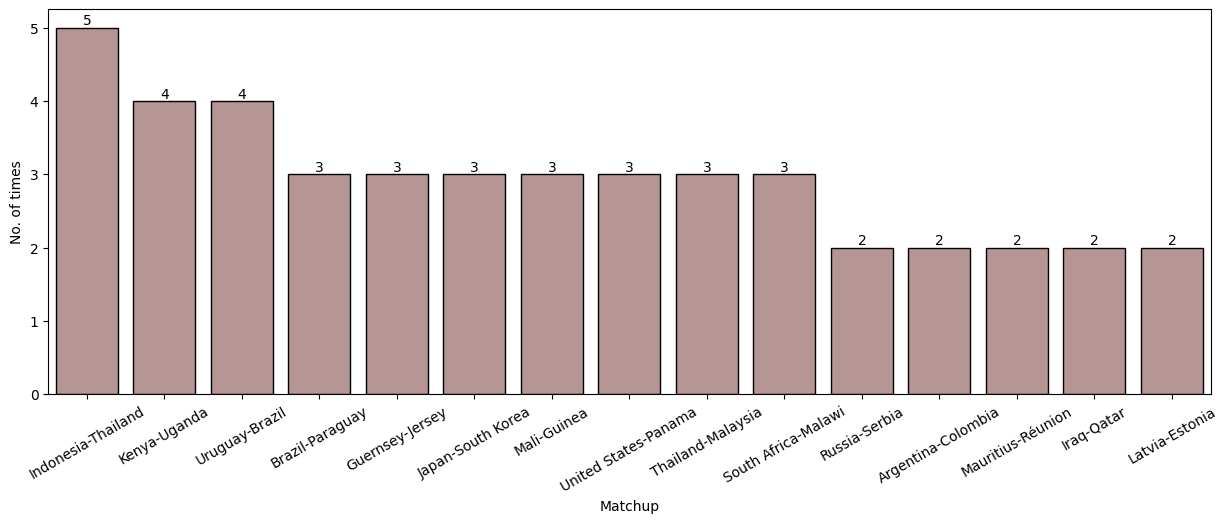

In [108]:
most_matchups = shootouts['matchup'].value_counts().head(15)

plt.figure(figsize = (15,5))
ax = sns.barplot(x = most_matchups.index, y = most_matchups.values, color = 'rosybrown', edgecolor = 'black')
for bars in ax.containers:
    ax.bar_label(bars)
plt.xticks(rotation = 30)
plt.xlabel('Matchup')
plt.ylabel('No. of times')
plt.show()

### Insights & Analysis

* Egypt has the most shootout wins (16) followed by Argentina and South Korea (15)
* South Africa has appeared in the most shootouts (28) followed by Egypt (27) and Zambia and South Korea (25)
* Home team have won 53.88% of total shootouts which indicates advantage for home eam during shootouts
* The frequency of shootouts have steadily increased over time, peaking in 2010s followed by small decline
* Indonesia-Thailand is the most common shootout matchup (5) followed by Uruguay-Brazil and Kenya-Uganda (4)